In [2]:
###########################
# 1. Imports
###########################

from ultralytics import YOLO
from pathlib import Path

import torch
import shutil
import random
import matplotlib.pyplot as plt
from PIL import Image



In [3]:
###########################
# 2. Check Device
###########################

print("MPS available:", torch.backends.mps.is_available())



MPS available: True


In [4]:
###########################
# 3. Dataset Split
###########################

random.seed(42)

base = Path("data")

images_dir = base / "images"
labels_dir = base / "labels"

all_images = list(images_dir.glob("*"))

random.shuffle(all_images)

train_split = 0.75
val_split = 0.15

train_end = int(len(all_images) * train_split)
val_end = int(len(all_images) * (train_split + val_split))

train_files = all_images[:train_end]
val_files = all_images[train_end:val_end]
test_files = all_images[val_end:]

splits = {
    "train": train_files,
    "val": val_files,
    "test": test_files,
}

for split_name, files in splits.items():

    split_images_dir = base / split_name / "images"
    split_labels_dir = base / split_name / "labels"

    split_images_dir.mkdir(parents=True, exist_ok=True)
    split_labels_dir.mkdir(parents=True, exist_ok=True)

    for img_path in files:

        label_path = labels_dir / f"{img_path.stem}.txt"

        shutil.copy(
            img_path,
            split_images_dir / img_path.name
        )

        if label_path.exists():
            shutil.copy(
                label_path,
                split_labels_dir / label_path.name
            )

print("Dataset split completed")



Dataset split completed


In [5]:
###########################
# 4. Create data.yaml
###########################

yaml_text = """
path: ./data

train: train/images
val: val/images
test: test/images

names:
  0: chair
"""

with open(base / "data.yaml", "w") as f:
    f.write(yaml_text)

print("data.yaml created")



data.yaml created


In [6]:
###########################
# 5. Load YOLO Model
###########################

model = YOLO("yolov8n.pt")

print("YOLO model loaded")



YOLO model loaded


In [7]:
###########################
# 6. Train Model
###########################

model.train(
    data="data/data.yaml",
    epochs=30,
    imgsz=640,
    batch=8,
    device="mps"
)

print("Training completed")



Ultralytics 8.4.49 🚀 Python-3.11.9 torch-2.11.0 MPS (Apple M3 Pro)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, p

In [8]:
###########################
# 7. Evaluate Model
###########################

metrics = model.val()

print(metrics)



Ultralytics 8.4.49 🚀 Python-3.11.9 torch-2.11.0 CPU (Apple M3 Pro)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 7576.4±287.4 MB/s, size: 3524.3 KB)
val: Scanning /Users/user/PycharmProjects/Learning/AI/projects/chair-detection-yolo/data/val/labels.cache... 10 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10/10 10.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.0s/it 1.0s
                   all         10         62      0.891       0.71      0.837       0.48
Speed: 0.7ms preprocess, 49.2ms inference, 0.0ms loss, 7.2ms postprocess per image
Results saved to /Users/user/PycharmProjects/Learning/AI/runs/detect/val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x1416e

In [9]:
###########################
# 8. Run Predictions
###########################

model.predict(
    source="data/test/images",
    save=True,
    conf=0.25
)

print("Prediction completed")




image 1/7 /Users/user/PycharmProjects/Learning/AI/projects/chair-detection-yolo/data/test/images/023da063-photo_2026-05-13_11.34.28.jpeg: 640x480 9 chairs, 26.4ms
image 2/7 /Users/user/PycharmProjects/Learning/AI/projects/chair-detection-yolo/data/test/images/0a1e7db5-IMG_20260513_111052.jpg: 640x480 8 chairs, 22.3ms
image 3/7 /Users/user/PycharmProjects/Learning/AI/projects/chair-detection-yolo/data/test/images/11f6692e-IMG_20260513_111246.jpg: 640x480 13 chairs, 26.9ms
image 4/7 /Users/user/PycharmProjects/Learning/AI/projects/chair-detection-yolo/data/test/images/35549ec1-IMG_20260513_111043.jpg: 640x480 10 chairs, 23.5ms
image 5/7 /Users/user/PycharmProjects/Learning/AI/projects/chair-detection-yolo/data/test/images/5c3eafcb-IMG_20260513_111612.jpg: 640x480 6 chairs, 20.9ms
image 6/7 /Users/user/PycharmProjects/Learning/AI/projects/chair-detection-yolo/data/test/images/bccda5d7-IMG_20260513_111109.jpg: 640x480 9 chairs, 23.1ms
image 7/7 /Users/user/PycharmProjects/Learning/AI/proj

Found 173 images


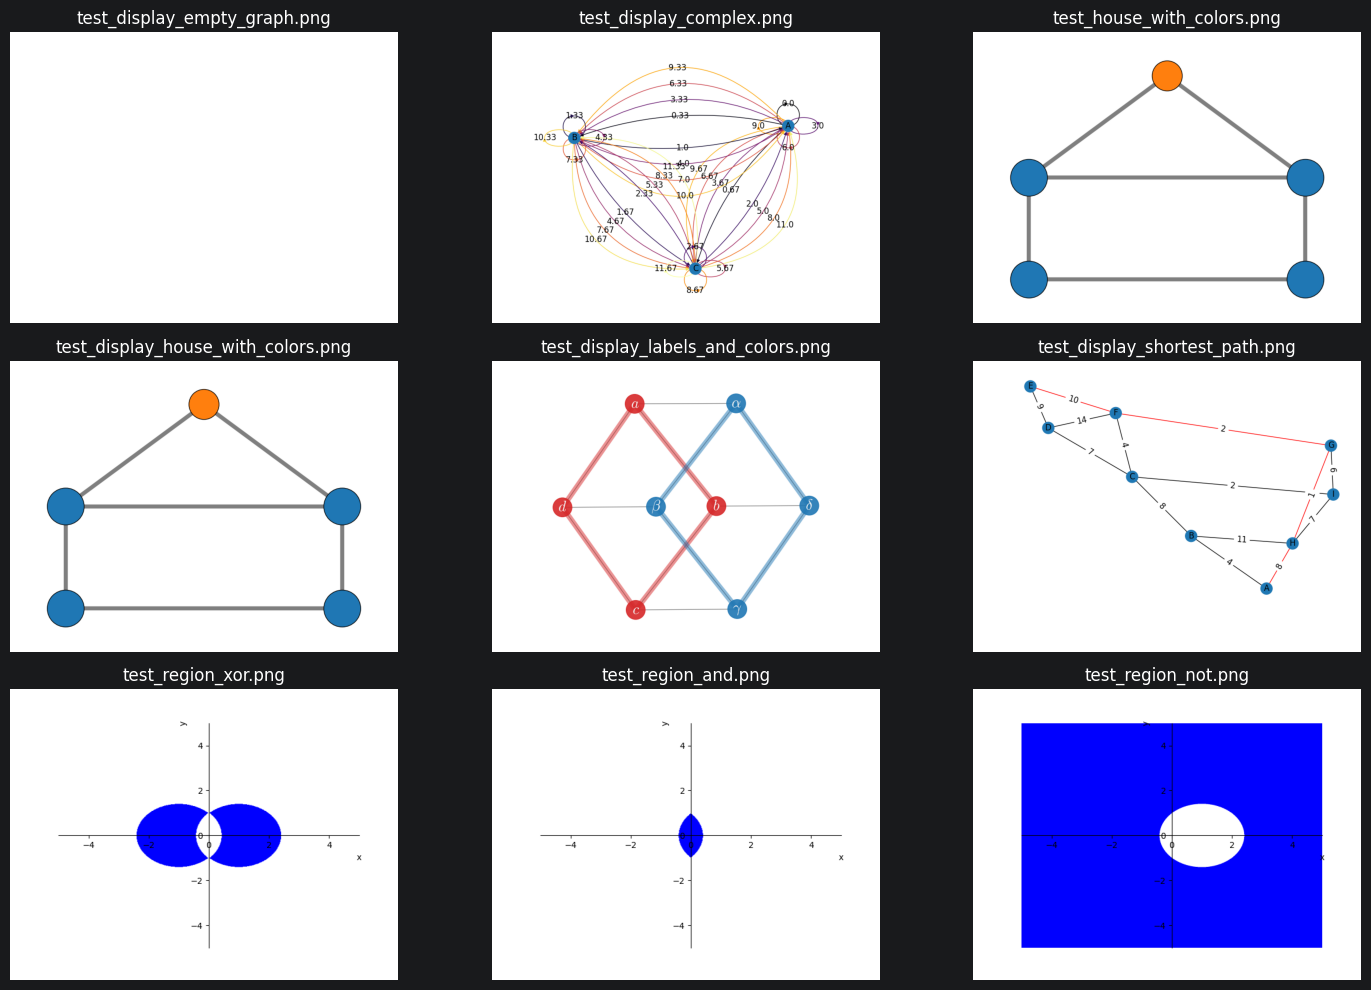

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

# Автопоиск изображений
prediction_images = []

for ext in ("*.png", "*.jpg", "*.jpeg", "*.bmp"):
    prediction_images.extend(Path(".").rglob(ext))

print(f"Found {len(prediction_images)} images")

if not prediction_images:
    print("Изображения не найдены")
    print("Текущая папка:", Path.cwd())

else:
    prediction_images = prediction_images[:9]

    fig, axes = plt.subplots(3, 3, figsize=(15, 10))
    axes = axes.flatten()

    for ax in axes:
        ax.axis("off")

    for i, img_path in enumerate(prediction_images):
        img = Image.open(img_path)

        axes[i].imshow(img)
        axes[i].set_title(img_path.name)

    plt.tight_layout()
    plt.show()

In [11]:
###########################
# 10. Model Paths
###########################

print("Best model:")
print("runs/detect/train/weights/best.pt")

print("\nPrediction images:")
print("runs/detect/predict/")

Best model:
runs/detect/train/weights/best.pt

Prediction images:
runs/detect/predict/
